almudenaris_Técnicas de Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Caso Grupal: Clasificación de mensajes de odio

## Objetivos

Mediante este trabajo se pretende que el estudiante ponga en práctica la aplicación de un proceso completo de machine learning a la clasificación de mensajes de odio.

El objetivo es generar un proyecto completo de machine learning para clasificar mensajes de odio. Debe detallar los pasos que hay que realizar para la clasificación de mensajes, así como una evaluación de los resultados.

- Decidir la técnica de aprendizaje automático a utilizar
- Analizar diferentes modelos de aprendizaje supervisado para la clasificación de mensajes de odio.
- Evaluar los resultados obtenidos por cada modelo en términos de precisión, recall, y f1.

## Descripción de la actividad

La empresa SureTech Innovations quiere implementar un clasificador de mensajes de odio. Para ello se deben entrenar diferentes modelos de clasificación, evaluar el rendimiento de cada uno de ellos, y finalmente, decidir cuál sería el mejor.

Para llevar a cabo esta actividad cuentas con el dataset simplificado de HateSpeech en la siguiente URL: https://github.com/almudenaris/TAA/blob/main/out.csv

Los pasos que se deben seguir para desarrollar esta actividad son:

1.	¿Qué tarea de aprendizaje automático se pretende resolver? ¿Qué análisis previos serían necesarios realizar para saber si es posible construir el modelo que buscamos? Realiza un análisis exploratorio de datos adecuado a la tarea que se pretende resolver y al dataset facilitado. Explica con detalle, en base a la tarea que se quiere resolver, qué análisis serían necesarios realizar sobre los datos.

2.	En base a la tarea que se pide realizar y a las características del dataset decide qué algoritmo o algoritmos se deben utilizar. Implementa tres modelos. Realiza los entrenamientos necesarios para cada uno de ellos. Explica por qué son convenientes los algoritmos elegidos.

3.	Realiza una explicación de las métricas de evaluación que se deben utilizar para valorar la bondad del modelo. Justifica la decisión de las elegidas. ¿Cómo habría que evaluar el modelo? Evalúa los modelos entrenados en el punto anterior y explica los resultados obtenidos.


## Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:

- Eliminación de nulos y duplicados
- Eliminación de URLs, emojis y menciones a los periódicos
- Eliminación de filas vacías
- Limpieza y homogeneización de datos.
    - Convertir la totalidad del texto a minúscula
    - Eliminar signos de puntuación
    - Eliminar números
    - Eliminar espacios en blanco adicionales
    - Eliminar palabras con longitud menor a 2 caracteres
    - Eliminar stopwords
    - Tokenización
    - Lematización
- Proceso de extracción de características
    - Conteo de palabras positivas (A)
    - Conteo de palabras negativas (B)
    - Conteo del número de bigrams más comunes (C)
    - Conteo del número de menciones a otros usuarios (D)
    - Categoría del sentimiento según librería ‘pysentimiento’ en español (E)

- Estandarización de las características (A_t,..E_t)
- Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

## EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./out.csv')

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

   A   B   C  D  E                                         comentario  label  \
0  2  64  30  0  2  pandemia,originado,covid,cierto,incidencia,aba...    0.0   
1  4  70  21  0  0  ser,mes,larga,espera,llegar,momento,siempre,pr...    0.0   
2  4  88  50  0  0  cartagena,san,sebastiar,fuengirola,irun,orense...    0.0   
3  3  38  21  0  0  pleno,dia,verano,calor,plan,mas,apetecibl,disf...    0.0   
4  0  59  17  0  0  pasado,junio,celebro,dia,luchar,frente,leishma...    0.0   

        A_t       B_t        C_t  ...    Valor_1    Valor_2   Valor_3  \
0  1.851102  2.759647   7.145831  ...   5.108388  13.227660 -0.771127   
1  3.990202  3.054765   4.877255  ...  12.189130  19.461233 -1.662227   
2  3.990202  3.940120  12.187108  ...  15.721875  48.629021 -1.662227   
3  2.920652  1.480801   4.877255  ...   4.324903  14.244765 -1.216677   
4 -0.287998  2.513715   3.869000  ...  -0.723945  -1.114264  0.119973   

    Valor_4    Valor_5   Valor_6   Valor_7   Valor_8   Valor_9  Valor_10  
0  0.

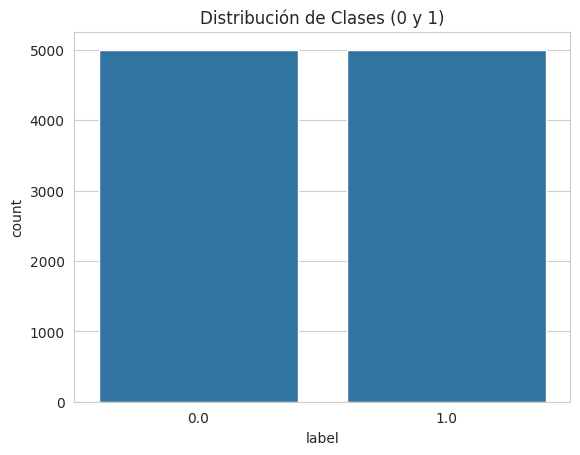

label
0.0    5000
1.0    5000
Name: count, dtype: int64


In [ ]:
sns.countplot(x='label', data=df)
plt.title('Distribución de Clases (0 y 1)')
plt.show()
print(df['label'].value_counts())

El análisis inicial de los datos revela un conjunto de datos balanceado en cuanto a clases (odio y no odio), lo cual facilitará el modelado.

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def palabras_mas_frecuentes(df, clase, n=20):
    palabras = Counter()
    for mensaje in df[df['label'] == clase]['comentario']:
        for palabra in mensaje.split():
            if palabra not in stopwords.words('spanish'):
                palabras[palabra] += 1
    return palabras.most_common(n)

palabras_odio = palabras_mas_frecuentes(df, 1)  # Clase 1: Odio
palabras_no_odio = palabras_mas_frecuentes(df, 0)  # Clase 0: No odio

print("Palabras más frecuentes en mensajes de odio:", palabras_odio)
print("Palabras más frecuentes en mensajes sin odio:", palabras_no_odio)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/santiago/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Palabras más frecuentes en mensajes de odio: [('terrorismo,informativo,', 89), ('terrorista,informativo,', 37), ('hdlgp,', 21), ('sinverguenza,', 16), ('hijo,puto,', 15)]
Palabras más frecuentes en mensajes sin odio: [('poder,seguir,babelia,facebook,twitter,apuntarte,aqui,recibir,newsletter,semanal,', 24), ('guardia,civil,evacuado,persona,afectado,nuevo,volcar,palma,canarias,entrar,erupcion,domingo,hora,local,montaña,rajado,zona,forestal,cabeza,vaco,paso,nivel,emergencia,pasado,semaforo,rojo,islir,hora,local,afectar,municipio,tazacortar,paso,fuencaliente,mazo,llano,aridane,uno,persona,total,ser,evacuar,vecino,zón,alcala,paraiso,iniciado,evacuacion,barrio,pasar,llano,aridane,tazacortir,prevision,avance,lenguo,lavo,autoridad,creer,total,podriar,ser,evacuar,persona,recomendar,poblacion,cerrar,todo,ventana,puerta,exterior,bajar,persiana,cerrar,suministro,agua,gas,electricidad,dirijar,punto,reunion,establecido,,previsible,evacuar,nadie,mas,lava,caminar,hacia,costa,daño,,ser,material,,asegur

Una vez hemos identificado la distribución de clases podemos observar cuales son aquellas palabras más frecuentes en cada uno de los conjuntos marcados como odio y no odio, esto nos ayuda a identificar patrones comunes al momento de realizar las evaluaciones y observar cuales palabras son más influyentes en los entrenamientos de nuestros modelos.

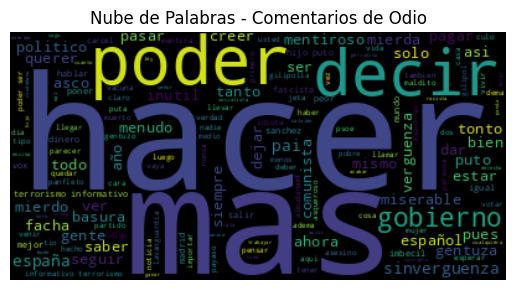

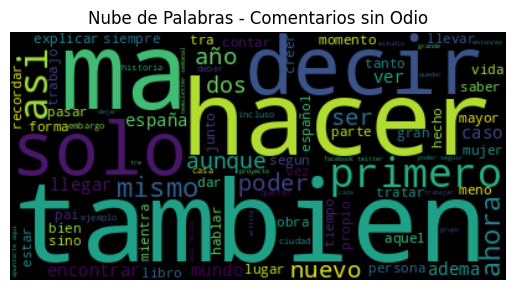

In [ ]:
from wordcloud import WordCloud

text_odio = " ".join(df[df['label'] == 1]['comentario'])
wordcloud_odio = WordCloud().generate(text_odio)
plt.imshow(wordcloud_odio, interpolation='bilinear')
plt.axis("off")
plt.title('Nube de Palabras - Comentarios de Odio')
plt.show()


text_odio = " ".join(df[df['label'] == 0]['comentario'])
wordcloud_odio = WordCloud().generate(text_odio)
plt.imshow(wordcloud_odio, interpolation='bilinear')
plt.axis("off")
plt.title('Nube de Palabras - Comentarios sin Odio')
plt.show()

 Se identificaron palabras clave distintivas asociadas al odio, como insultos y lenguaje despectivo, así como patrones léxicos más neutros en los mensajes sin odio. La visualización de nubes de palabras confirmaestas tendencias.

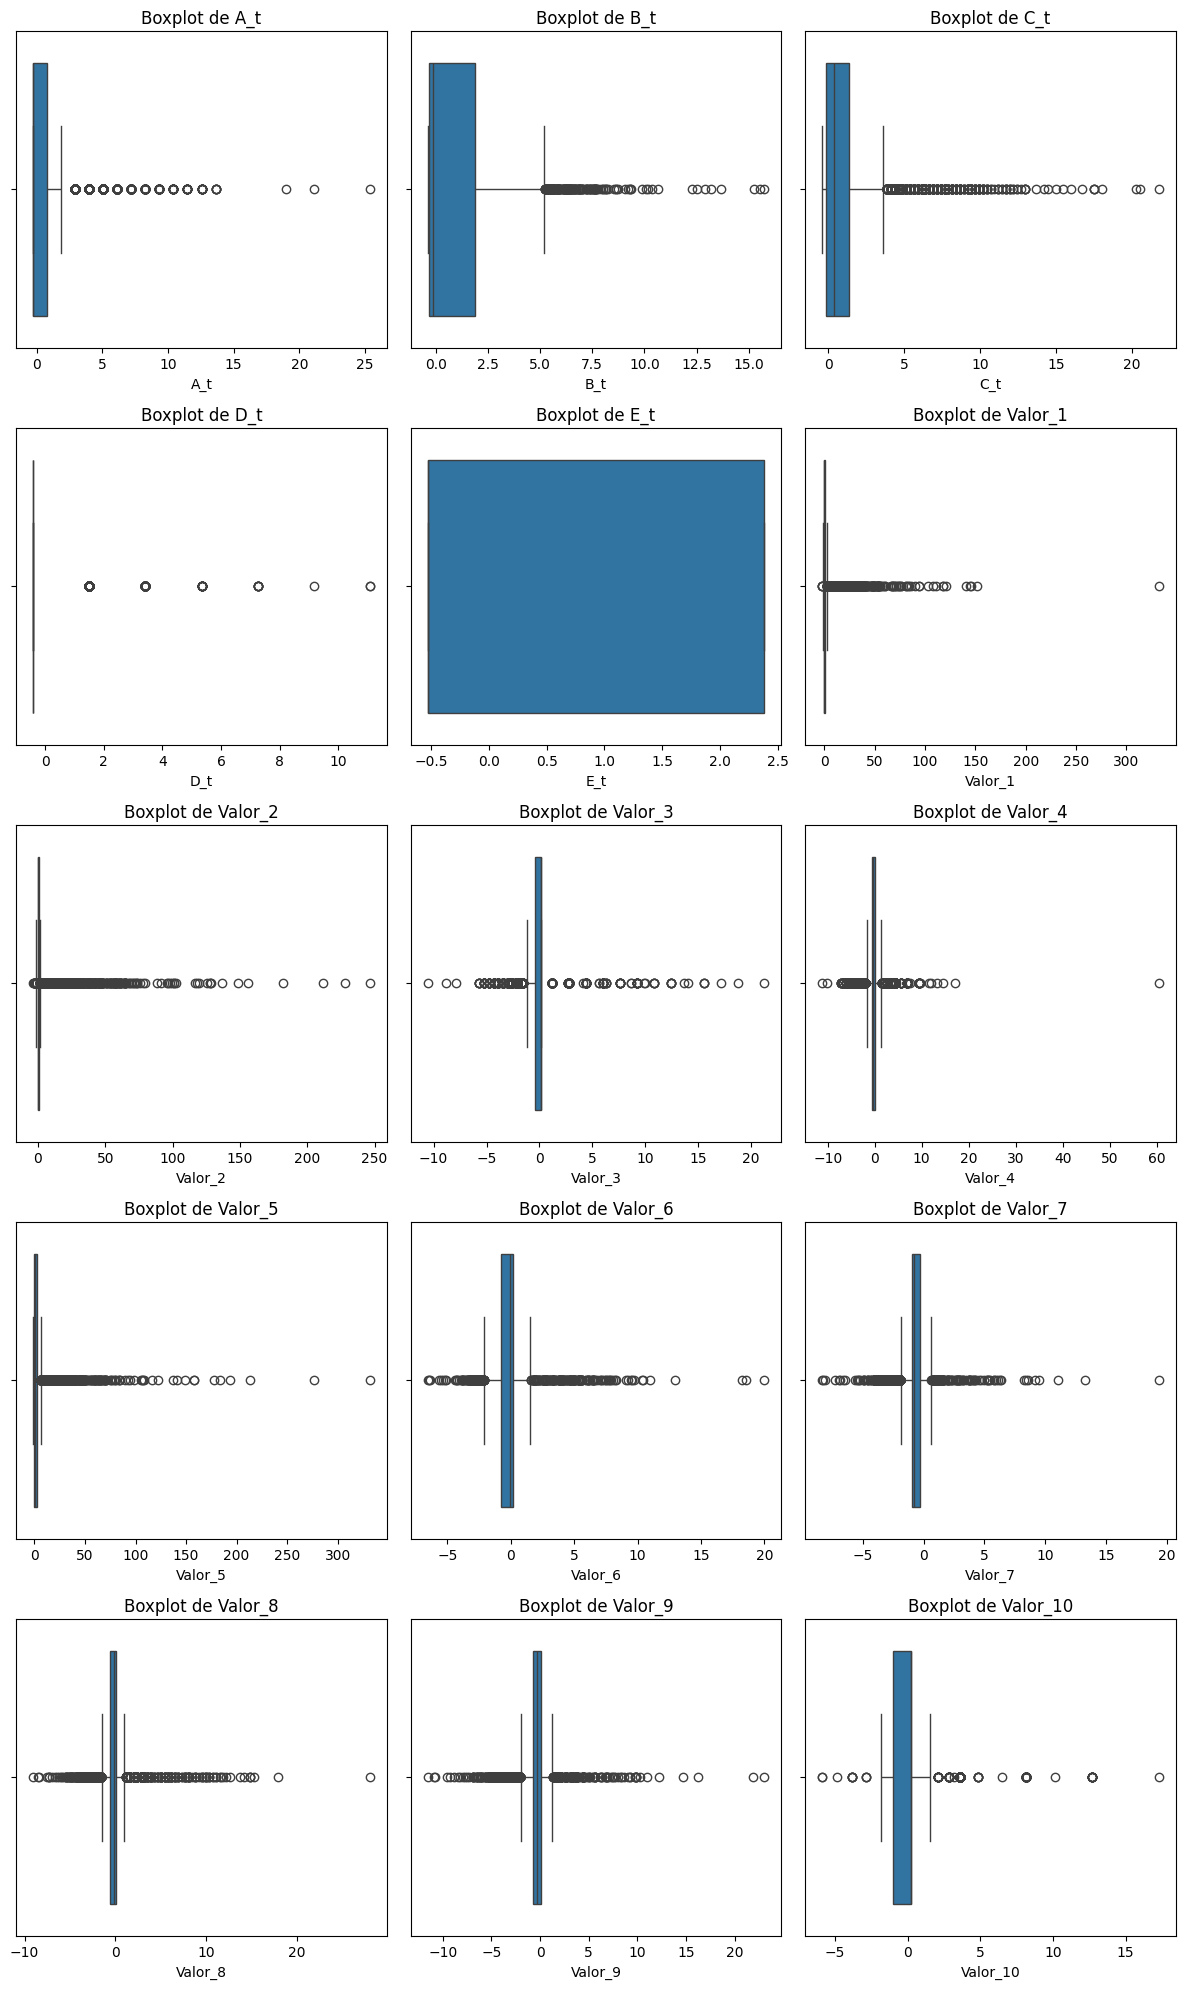

In [ ]:
import math

numeric_columns = df[['A_t', 'B_t', 'C_t', 'D_t', 'E_t', 'Valor_1', 'Valor_2',
        'Valor_3', 'Valor_4', 'Valor_5', 'Valor_6', 'Valor_7',
        'Valor_8', 'Valor_9', 'Valor_10']].columns
num_columns = len(numeric_columns)

num_cols_grilla = 3
num_rows_grilla = math.ceil(num_columns / num_cols_grilla)

fig, axs = plt.subplots(num_rows_grilla, num_cols_grilla, figsize=(12, num_rows_grilla * 4))

axs = axs.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axs[i])
    axs[i].set_title(f"Boxplot de {col}")
    axs[i].set_xlabel(col)

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

Cuando estemos realizando la evaluación de los diferentes modelos necesitamos conocer la distribución de los mismos para ver si es necesario realizar limpieza de los valores outliers y que podrian afectar el rendimiento de los diferentes modelos. En este caso notamos la presencia de outliers en las características originales y combinadas, lo cual sera necesario tratar en el rendimiento de algunos modelos seleccionados.



In [ ]:
matriz_correlacion_original = df[['A', 'B', 'C', 'D', 'E']].corr()

matriz_correlacion_estandarizada = df[['Valor_1', 'Valor_2', 'Valor_3', 'Valor_4',
                                         'Valor_5', 'Valor_6', 'Valor_7', 'Valor_8',
                                         'Valor_9', 'Valor_10']].corr()

print(matriz_correlacion_original)
print(matriz_correlacion_estandarizada)

          A         B         C         D         E
A  1.000000  0.574179  0.514770 -0.035345 -0.291708
B  0.574179  1.000000  0.789388 -0.076351 -0.558321
C  0.514770  0.789388  1.000000 -0.033210 -0.369224
D -0.035345 -0.076351 -0.033210  1.000000  0.088191
E -0.291708 -0.558321 -0.369224  0.088191  1.000000
           Valor_1   Valor_2   Valor_3   Valor_4   Valor_5   Valor_6  \
Valor_1   1.000000  0.891394 -0.371382 -0.406024  0.679444 -0.301878   
Valor_2   0.891394  1.000000 -0.320527 -0.323569  0.749874 -0.253945   
Valor_3  -0.371382 -0.320527  1.000000  0.127685 -0.214117  0.600511   
Valor_4  -0.406024 -0.323569  0.127685  1.000000 -0.240279  0.150229   
Valor_5   0.679444  0.749874 -0.214117 -0.240279  1.000000 -0.349921   
Valor_6  -0.301878 -0.253945  0.600511  0.150229 -0.349921  1.000000   
Valor_7  -0.430566 -0.357379  0.168250  0.421636 -0.476069  0.291330   
Valor_8  -0.251941 -0.284778  0.559437  0.107497 -0.387041  0.810193   
Valor_9  -0.367147 -0.412460  0.143613  

Se observó multicolinealidad en las características estandarizadas, producto de la combinación de las características originales.

In [ ]:
from scipy.stats import f_oneway
correlations = {}
for col in numeric_columns:
    correlations[col] = df[col].corr(df['label'])

sorted_features = sorted(correlations, key=lambda x: abs(correlations[x]), reverse=True)

print("Correlaciones de las features con 'label':")
for col in sorted_features:
    print(f"{col}: {correlations[col]:.3f}")

print("\nResultados del análisis de varianza (ANOVA):")
for col in sorted_features:
    grupo_no_odio = df[df['label'] == 0][col]
    grupo_odio = df[df['label'] == 1][col]

    f_valor, p_valor = f_oneway(grupo_no_odio, grupo_odio)
    print(f"Feature: {col} - F: {f_valor:.3f}, p-value: {p_valor:.3f}")


    if p_valor < 0.05:
        print("  -> Diferencias significativas entre los grupos (p < 0.05)")
    else:
        print("  -> No se encontraron diferencias significativas (p >= 0.05)")

top_features = sorted_features[:5]

print("\n5 primeras features con mayor correlación")

print(top_features)

Correlaciones de las features con 'label':
E_t: 0.755
B_t: -0.731
C_t: -0.510
Valor_9: 0.396
A_t: -0.380
Valor_6: 0.341
Valor_5: -0.316
Valor_1: -0.280
Valor_7: 0.265
Valor_2: -0.251
Valor_8: 0.234
Valor_4: 0.226
Valor_10: -0.180
Valor_3: 0.161
D_t: 0.130

Resultados del análisis de varianza (ANOVA):
Feature: E_t - F: 13252.708, p-value: 0.000
  -> Diferencias significativas entre los grupos (p < 0.05)
Feature: B_t - F: 11485.315, p-value: 0.000
  -> Diferencias significativas entre los grupos (p < 0.05)
Feature: C_t - F: 3509.652, p-value: 0.000
  -> Diferencias significativas entre los grupos (p < 0.05)
Feature: Valor_9 - F: 1861.680, p-value: 0.000
  -> Diferencias significativas entre los grupos (p < 0.05)
Feature: A_t - F: 1688.112, p-value: 0.000
  -> Diferencias significativas entre los grupos (p < 0.05)
Feature: Valor_6 - F: 1315.609, p-value: 0.000
  -> Diferencias significativas entre los grupos (p < 0.05)
Feature: Valor_5 - F: 1106.418, p-value: 0.000
  -> Diferencias signif

Al realizar un análisis de varianza notamos que todas las caracteristicas de nuestro dataset tienen una alta correlación con nuestra variable objetivo lo que nos facilita el análisis e impacto que tendran cada una de estas caracteristicas en las predicciones de los modelos.

## Conclusiones del EDA

- Notamos que nuestro dataset esta balanceado y esta dividido en partes iguales para nuestras clases (odio y no odio)
- Existen palabras y patrones léxicos despectivos comunes en comentarios de odio versus palabras y patrones más neutros en los comentarios sin odio.
- La estandarización de las caracteristicas demostró que existe muchos valores atipicos que deberan ser tratados para los modelos que son sensibles a estas variaciones.
- Notamos multicolinealidad entre las caracteristicas estandarizadas tanto para el analisis de correlaciones como el análisis de varianza


Para este análisis estamos intentando crear modelos que permitan clasificar comentarios basados en las caracteristicas A,B,C,D y E y evaluar el rendimiento de diferentes modelos.


## Modelos Seleccionados para Evaluación

1. **Random Forest**: se eligió como modelo inicial debido a su robustez ante la multicolinealidad y la presencia de outliers, dos aspectos importantes identificados en el análisis de los datos. Además, Random Forest es un modelo versátil que suele ofrecer buenos resultados en tareas de clasificación de texto y no requiere un ajuste tan exhaustivo de hiperparámetros como otros modelos más complejos. En resumen, Random Forest presenta un equilibrio entre rendimiento, robustez y facilidad de uso que lo convierte en un candidato adecuado para abordar la tarea de clasificación de mensajes de odio.
2. **SVM:** Se eligió SVM como segundo modelo debido a su capacidad de separar conjuntos mediante hiperplanos y en este caso al ser una clasificación binaria SVM tomaría menor tiempo de entrenamiento y evaluación. Además que es es un modelo robusto a alta dimensionalidad y funciona bien para datasets con clases balanceadas (que es nuestro caso).


## SELECCIÓN Y ENTRENAMIENTO DE LOS MODELOS

Fitting 3 folds for each of 81 candidates, totalling 243 fits
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1012
         1.0       0.98      0.98      0.98       988

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



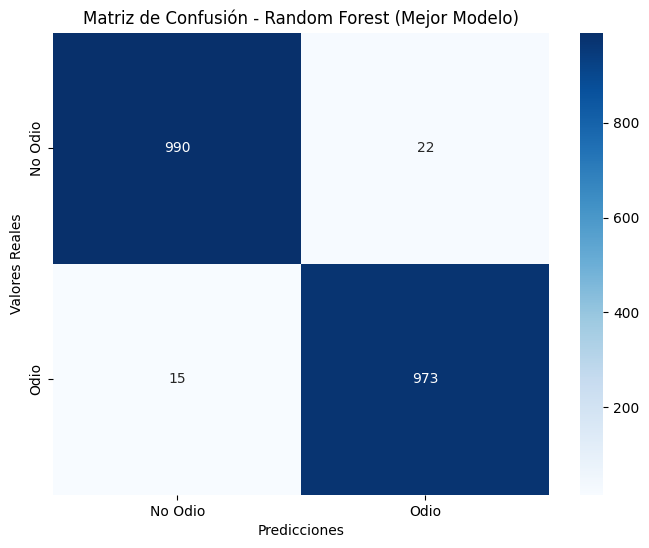

Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

X = df[['A_t', 'B_t', 'C_t', 'D_t', 'E_t', 'Valor_1', 'Valor_2',
        'Valor_3', 'Valor_4', 'Valor_5', 'Valor_6', 'Valor_7',
        'Valor_8', 'Valor_9', 'Valor_10']]
y = df['label']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definición de la grilla de hiperparámetros a explorar
param_grid = {
    'n_estimators': [50, 100, 200],  # Número de árboles en el bosque
    'max_depth': [None, 10, 20],  # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10],  # Número mínimo de muestras para dividir un nodo
    'min_samples_leaf': [1, 2, 4]  # Número mínimo de muestras en un nodo hoja
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=2,
                           scoring='f1_weighted')

grid_search.fit(X_train, y_train)

mejor_modelo_rf = grid_search.best_estimator_

predicciones_rf = mejor_modelo_rf.predict(X_test)

# Evaluación del mejor modelo
print(classification_report(y_test, predicciones_rf))

# Matriz de confusión del mejor modelo
matriz_confusion_rf = confusion_matrix(y_test, predicciones_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusion_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Odio', 'Odio'], yticklabels=['No Odio', 'Odio'])
plt.title('Matriz de Confusión - Random Forest (Mejor Modelo)')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.show()

# Imprimir los mejores parámetros encontrados
print("Mejores parámetros encontrados:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros encontrados:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Mejor score en validación cruzada: 0.974

Resultados en el conjunto de prueba:
Accuracy: 0.9735
Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.99      0.95      0.97      1012
         1.0       0.96      0.99      0.97       988

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



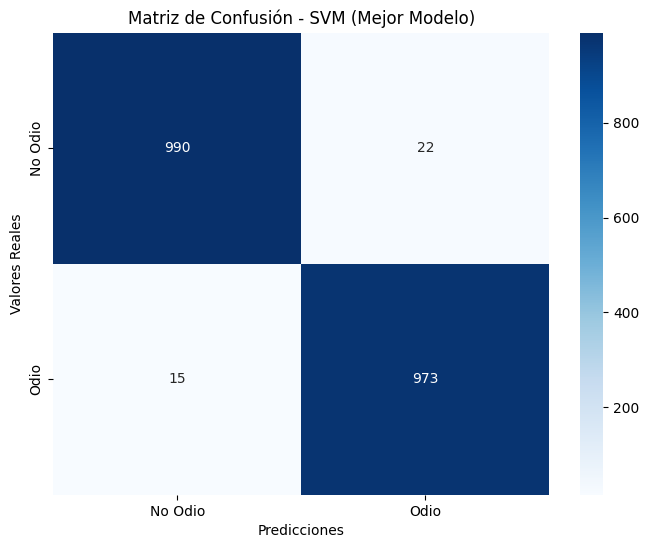

In [9]:
## Modelado con SVM
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=42))
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto']
}


svm_grid_search = GridSearchCV(
    pipeline,
    svm_param_grid,
    cv = 3,
    scoring = "f1_weighted",
    n_jobs=-1,
    verbose=2
)

svm_grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(svm_grid_search.best_params_)
print("\nMejor score en validación cruzada: {:.3f}".format(svm_grid_search.best_score_))


# Evaluar el modelo optimizado en el conjunto de prueba
svm_y_pred = svm_grid_search.predict(X_test)


svm_conf_matrix = confusion_matrix(y_test, svm_y_pred)
print("\nResultados en el conjunto de prueba:")
print("Accuracy:", accuracy_score(y_test, svm_y_pred))
print("Reporte de clasificación:\n", classification_report(y_test, svm_y_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusion_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Odio', 'Odio'], yticklabels=['No Odio', 'Odio'])
plt.title('Matriz de Confusión - SVM (Mejor Modelo)')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.show()

## EVALUACIÓN DE LOS MODELOS Y COMPARATIVA

In [ ]:
# coloca tu código y respuestas del punto 3 en esta sección